# Разбиение запросов с множеством CTE

Кратко по функциям

* getCteSrc(sql: str) -> Dict[str,str]]: создает словарь CTE запросов, включая финальный
    * ключ - имя
    * значение - тело  
* getCteDeps(Dict[str,str]) -> Dict[str,List[str]]: создает словарь зависимостей CTE
    * ключ - имя,
    * значение - список используемых объектов (часть из которых - CTE)
* genDepGraph(cteDeps,bigTables): рисует граф зависимостей (от CTE)
* genCte(cte,cteSrc,cteDeps,cteExcl): генерирует запрос, формирующий данные заданного cte
    * с учетом исключенных (материализованных) CTE
    * результаты этого запроса можно материализовать

## Тестирование

Тестировать буду на TPCDS с использованием DuckDB (синтаксис тот же, но не нужны сервера)

In [3]:
cteSQL = """ -- сгенерил deepseek по моему описанию
WITH store_sales_base AS ( -- Base CTE to get store sales data with relevant joins
    SELECT 
        ss.ss_sold_date_sk as date_sk,
        ss.ss_ticket_number,
        ss.ss_item_sk,
        ss.ss_customer_sk,
        ss.ss_quantity as quantity,
        d.d_date as sale_date,
        i.i_item_id,
        i.i_item_desc as item_name,
        c.c_customer_id,
        c.c_first_name || ' ' || c.c_last_name as customer_name
    FROM tpcds_10g.store_sales ss
    JOIN tpcds_10g.date_dim d ON ss.ss_sold_date_sk = d.d_date_sk
    JOIN tpcds_10g.item i ON ss.ss_item_sk = i.i_item_sk
    JOIN tpcds_10g.customer c ON ss.ss_customer_sk = c.c_customer_sk
    WHERE d.d_date BETWEEN '2000-01-01' AND '2000-12-31'  -- Example date range
)
, item_quantity AS ( -- CTE for item quantity details
    SELECT 
        sale_date as date,
        ss_ticket_number,
        ss_item_sk,
        item_name,
        quantity
    FROM store_sales_base
)
, customer_quantity AS ( -- CTE for customer quantity details
    SELECT 
        sale_date as date,
        ss_ticket_number,
        ss_customer_sk,
        customer_name,
        quantity
    FROM store_sales_base
)
,daily_quantity AS ( -- CTE for daily average quantity per item
    SELECT 
        sale_date as date,
        ss_item_sk,
        item_name,
        AVG(quantity) as average_daily_quantity
    FROM store_sales_base
    GROUP BY sale_date, ss_item_sk, item_name
)
, sales_combined AS ( -- Intermediate CTE to combine item and customer data
    SELECT 
        COALESCE(iq.date, cq.date) as date,
        cq.customer_name,
        iq.item_name,
        iq.quantity as item_quantity,
        cq.quantity as customer_quantity,
        iq.ss_ticket_number
    FROM item_quantity iq
    FULL OUTER JOIN customer_quantity cq 
        ON iq.ss_ticket_number = cq.ss_ticket_number 
        AND iq.date = cq.date
    WHERE iq.ss_ticket_number IS NOT NULL 
        AND cq.ss_ticket_number IS NOT NULL
)
, aggregated_sales AS ( -- CTE to aggregate quantities by date, customer, and item
    SELECT 
        sc.date,
        sc.customer_name,
        sc.item_name,
        SUM(sc.item_quantity) as total_quantity
    FROM sales_combined sc
    GROUP BY sc.date, sc.customer_name, sc.item_name
)
, final_with_averages AS ( -- CTE to join with daily averages
    SELECT 
        a.date,
        a.customer_name,
        a.item_name,
        dq.average_daily_quantity,
        a.total_quantity as sum_quantity
    FROM aggregated_sales a
    LEFT JOIN daily_quantity dq 
        ON a.date = dq.date 
        AND a.item_name = dq.item_name
) 
-- END CTES

-- Final query with ordered results
SELECT 
    f.date,
    f.customer_name,
    f.item_name,
    ROUND(CAST(f.average_daily_quantity AS NUMERIC), 2) as average_daily_quantity,
    f.sum_quantity
FROM final_with_averages f
WHERE f.sum_quantity > f.average_daily_quantity  -- Show only above average purchases
ORDER BY 
    f.date,
    f.customer_name,
    f.item_name;
"""

In [2]:
import duckdb as ddb

In [3]:
conn = ddb.connect("~/mk_win/Documents/28.Arrow/data/tpcds_10g.duckdb")

Запрос работает, можно будет сравнить результаты с результатами программно обработанного запроса

In [10]:
conn.sql(cteSQL)

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

┌────────────┬────────────────┬────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────┬────────────────────────┬──────────────┐
│    date    │ customer_name  │                                                                                           item_name                                                                                            │ average_daily_quantity │ sum_quantity │
│    date    │    varchar     │                                                                                            varchar                                                                                             │     decimal(18,2)      │    int128    │
├────────────┼────────────────┼──────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────

## Прогоны

In [1]:
from cte_tools import getCteSrc, getCteDeps, genCte, genGraph

### На TPC-DS тесте

Готовлю структуры данных

* Src: исходные коды CTE
* Deps: зависимости

In [4]:
tpcSrc = getCteSrc(cteSQL)

In [5]:
len(tpcSrc)

8

In [6]:
tpcDeps = getCteDeps(tpcSrc)

In [7]:
tpcDeps

{'store_sales_base': ['tpcds_10g.store_sales',
  'tpcds_10g.date_dim',
  'tpcds_10g.item',
  'tpcds_10g.customer'],
 'item_quantity': ['store_sales_base'],
 'customer_quantity': ['store_sales_base'],
 'daily_quantity': ['store_sales_base'],
 'sales_combined': ['item_quantity', 'customer_quantity'],
 'aggregated_sales': ['sales_combined'],
 'final_with_averages': ['aggregated_sales', 'daily_quantity'],
 'FinQ': ['final_with_averages']}

Смотрю граф зависимостей (просто визуальный анализ)

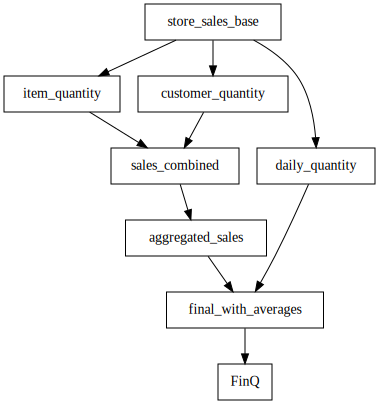

In [8]:
genGraph(tpcDeps)

In [14]:
matList = [ "store_sales_base", "aggregated_sales", "FinQ" ]

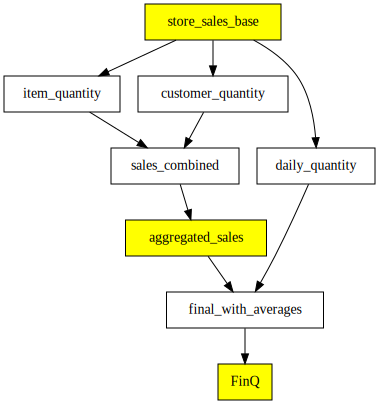

In [15]:
genGraph(tpcDeps,matCtes=matList)

In [16]:
reqList = [] # итоговый список запросов
aExcl = {} # словарь исключений

for cte in matList:
    matName = f"mat_{cte}_tmp"
    aSql = f"-- create table {matName} with ( appendoptimized=TRUE, compresstype=ZSTD, compresslevel=1 ) as\n"
    aSql += "-- explain analyze\n"
    aSql += "\n".join(genCte(cte,tpcSrc,tpcDeps,aExcl))
    aSql += "\n--distributed randomly"
    aSql += f"\n--analyze {matName}"
    aExcl[cte] = [f"select * from {matName}"] 
    reqList.append(aSql)

In [17]:
with open("test_tpc.sql", "w") as fp:
    for tName in matList:
        fp.write(f"drop table if exists mat_{tName}_tmp;\n")
    for req in reqList:
        fp.write(req)
        fp.write("\n\n-- ============================================================================\n\n")

#### Проверки корректности результатов

Вроде бы все работает ок...

Проверял на финальном запросе, который формируется с учетом материализаций

Проверил с одной и двумя материализациями - работает ОК

**В этот ноутбук собственно ячейки с запуском не включал**